# Correlations

In [1]:
import pickle
import torch
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

## Read in data

In [2]:
# Infectivity
mutation_file = 'results/mutation_infectivity_effects.csv'
infectivity = pd.read_csv(mutation_file)

In [3]:
# Neutralization
neutralization_file = 'results/mutation_neutralization_effects.csv'
neutralization = pd.read_csv(neutralization_file)

In [4]:
# PyR0
pyro_file = 'data/PyR0/2023-09-19/mutations.tsv'
pyro = pd.read_csv(pyro_file, sep='\t', usecols=['mutation', 'R / R_A', 'R / R_A 95% ci lower', 'R / R_A 95% ci upper']).rename(columns={'mutation':'Mutation'})
pyro = pyro[pyro['Mutation'].str.startswith('S:')]
pyro['Mutation'] = pyro['Mutation'].apply(lambda x: x[2:])

In [5]:
# BVAS
bvas_file = 'data/BVAS/2023-09-20/allele_summary.csv'
bvas = pd.read_csv(bvas_file).rename(columns={'Unnamed: 0':'Mutation'}).drop(columns='Rank')
bvas = bvas[bvas['Mutation'].str.startswith('S:')]
bvas['Mutation'] = bvas['Mutation'].apply(lambda x: x[2:])

In [6]:
# Join
df = pd.DataFrame()
df = pd.merge(infectivity, neutralization, on='Mutation', suffixes=[' Infectivity', ' Neutralization'])
df = pd.merge(df, pyro, on='Mutation', suffixes=['', ''])
df = pd.merge(df, bvas, on='Mutation', suffixes=['', ''])
df = df.rename(columns={'R / R_A':'R / R_A (PyR0)', 'PIP':'PIP (BVAS)', 'Beta':'Beta (BVAS)'})
df

,Mutation,Mean Infectivity,Std Infectivity,Mean Neutralization,Std Neutralization,R / R_A (PyR0),R / R_A 95% ci lower,R / R_A 95% ci upper,PIP (BVAS),Beta (BVAS),BetaStd,ConditionalBeta,ConditionalBetaStd
0,V213G,0.463965,0.223137,0.092484,0.083188,1.057070,1.057030,1.05711,0.012438,-0.000046,0.009131,-0.006068,0.105169
1,Q493R,0.164338,0.099971,-0.245807,0.046967,0.962116,0.961992,0.96224,1.000000,-0.532805,0.071332,-0.532805,0.071332
2,R346T,0.008609,0.091487,-0.366572,0.037807,1.167680,1.167250,1.16812,1.000000,0.379058,0.024746,0.379058,0.024746
3,R346K,-0.046916,0.213577,0.013803,0.066684,1.098130,1.098090,1.09818,1.000000,0.335846,0.023385,0.335846,0.023385
4,T19R,-0.127570,0.190905,-0.014030,0.061515,1.007000,1.006960,1.00704,0.900275,0.275853,0.134424,0.309105,0.099849
5,T76I,-0.455236,0.141814,-0.118947,0.106023,1.031250,1.031040,1.03146,1.000000,-0.168680,0.025677,-0.168680,0.025677
6,L452R,-0.694807,0.121618,-0.208726,0.053781,1.176720,1.176530,1.17691,1.000000,0.510087,0.041544,0.510087,0.041544
7,G339D,-0.718445,0.156088,-0.385538,0.062997,1.054520,1.054440,1.05460,0.017432,0.000910,0.010515,0.054853,0.060890
8,T478K,-0.759696,0.239030,0.315366,0.106638,1.388530,1.385010,1.39205,0.007356,-0.000125,0.013750,-0.001110,0.040941


#### Quick correlation

In [7]:
df[['Mean Infectivity', 'Mean Neutralization', 'R / R_A (PyR0)', 'Beta (BVAS)', 'PIP (BVAS)']].corr()

,Mean Infectivity,Mean Neutralization,R / R_A (PyR0),Beta (BVAS),PIP (BVAS)
Mean Infectivity,1.000000,0.020330,-0.513277,-0.196020,0.163453
Mean Neutralization,0.020330,1.000000,0.479729,-0.021074,-0.379173
R / R_A (PyR0),-0.513277,0.479729,1.000000,0.363702,-0.353771
Beta (BVAS),-0.196020,-0.021074,0.363702,1.000000,0.194167
PIP (BVAS),0.163453,-0.379173,-0.353771,0.194167,1.000000


## Compare neutralization & infectivity with each other

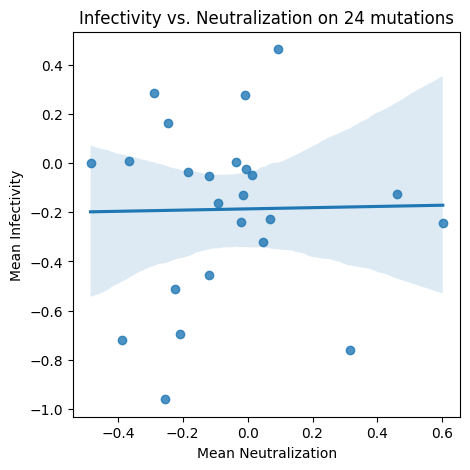

In [8]:
# Neutralization vs Infectivity
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Neutralization',
            y='Mean Infectivity',
            data=pd.merge(neutralization, infectivity, on='Mutation', suffixes = [' Neutralization', ' Infectivity']),
            ax=ax);

inf_muts = set(infectivity.Mutation)
neut_muts = set(neutralization.Mutation)

ax.set_title('Infectivity vs. Neutralization on {} mutations'.format(len(inf_muts&neut_muts)));

## Infectivity & Neutralization vs Predicted Growth Rate (PyR0 and BVAS)

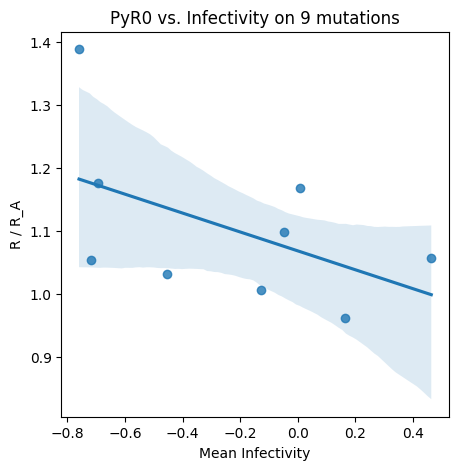

In [9]:
# Infectivity vs PyR0
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Infectivity',
            y='R / R_A',
            data=pd.merge(infectivity, pyro, on='Mutation').rename(columns={'Mean':'Mean Infectivity'}),
            ax=ax);

pyro_muts = set(pyro.Mutation)
inf_muts = set(infectivity.Mutation)

ax.set_title('PyR0 vs. Infectivity on {} mutations'.format(len(pyro_muts&inf_muts)));

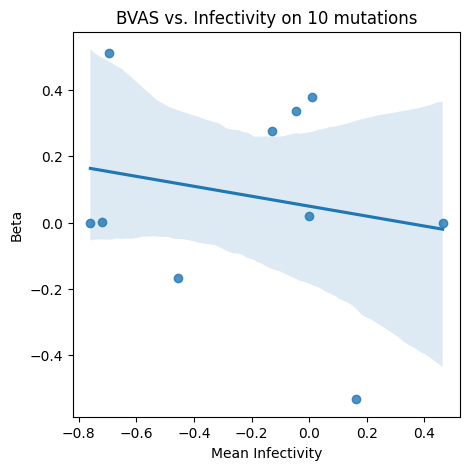

In [10]:
# Infectivity vs BVAS Beta
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Infectivity',
            y='Beta',
            data=pd.merge(infectivity, bvas, on='Mutation').rename(columns={'Mean':'Mean Infectivity'}),
            ax=ax);

bvas_muts = set(bvas.Mutation)
neut_muts = set(neutralization.Mutation)

ax.set_title('BVAS vs. Infectivity on {} mutations'.format(len(bvas_muts&neut_muts)));

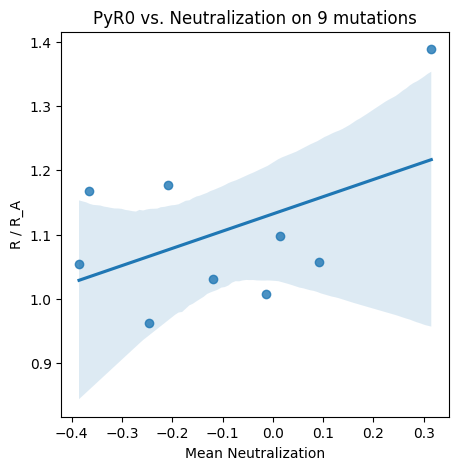

In [11]:
# Neutralization vs PyR0
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Neutralization',
            y='R / R_A',
            data=pd.merge(neutralization, pyro, on='Mutation').rename(columns={'Mean':'Mean Neutralization'}),
            ax=ax);

pyro_muts = set(pyro.Mutation)
neut_muts = set(neutralization.Mutation)

ax.set_title('PyR0 vs. Neutralization on {} mutations'.format(len(pyro_muts&neut_muts)));

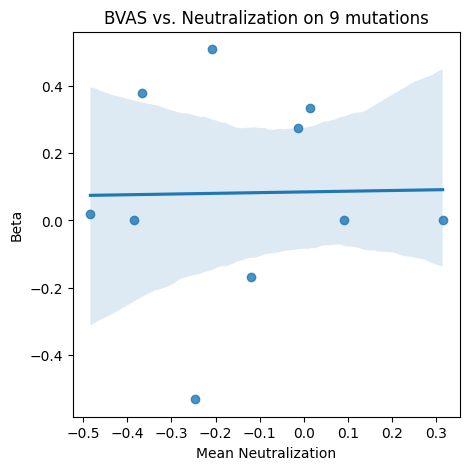

In [12]:
# Neutralization vs BVAS
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Neutralization',
            y='Beta',
            data=pd.merge(neutralization, bvas, on='Mutation').rename(columns={'Mean':'Mean Neutralization'}),
            ax=ax);

bvas_muts = set(bvas.Mutation)
neut_muts = set(neutralization.Mutation)

ax.set_title('BVAS vs. Neutralization on {} mutations'.format(len(pyro_muts&neut_muts)));

## Explore With DMS
DMS data from the paper [Deep Mutational Scanning of SARS-CoV-2 Receptor Binding Domain Reveals Constraints on Folding and ACE2 Binding](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7418704/). DMS for expression and ACE2 binding of the RBD can be found on [github](https://github.com/jbloomlab/SARS-CoV-2-RBD_DMS/blob/master/results/single_mut_effects/single_mut_effects.csv). For this repository, the data have been downloaded to the `data` subdirectory of this repository.

In [23]:
# Read in DMS data
filename = 'data/Bloom/single_mut_effects.txt'
columns = {#'site_SARS2':'position', 
           'mutation':'Mutation', 
           'bind_avg':'ACE2 Binding', 
           'expr_avg':'Expression'}
dms = pd.read_csv(filename, usecols=columns.keys()).rename(columns=columns)

In [24]:
df = pd.merge(neutralization, infectivity, on='Mutation', suffixes = [' Neutralization', ' Infectivity'])
df = pd.merge(df, dms, on='Mutation')
df[['Mean Neutralization', 'Mean Infectivity', 'ACE2 Binding', 'Expression']].corr()

,Mean Neutralization,Mean Infectivity,ACE2 Binding,Expression
Mean Neutralization,1.000000,-0.044571,-0.481782,0.394434
Mean Infectivity,-0.044571,1.000000,-0.154039,-0.140581
ACE2 Binding,-0.481782,-0.154039,1.000000,-0.196268
Expression,0.394434,-0.140581,-0.196268,1.000000


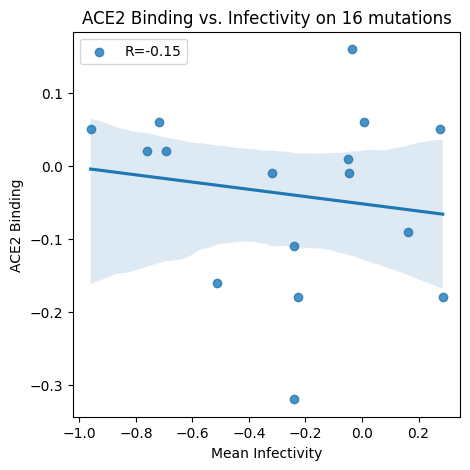

In [40]:
# Infectivity vs ACE2 Binding
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Infectivity',
            y='ACE2 Binding',
            data=pd.merge(infectivity, dms, on='Mutation').rename(columns={'Mean':'Mean Infectivity'}),
            label='R={:.2f}'.format(pd.merge(infectivity, dms, on='Mutation')[['Mean','ACE2 Binding']].corr().values[0,1]),
            ax=ax);
ax.legend()

ace_muts = set(dms.Mutation)
inf_muts = set(infectivity.Mutation)

ax.set_title('ACE2 Binding vs. Infectivity on {} mutations'.format(len(ace_muts&inf_muts)));

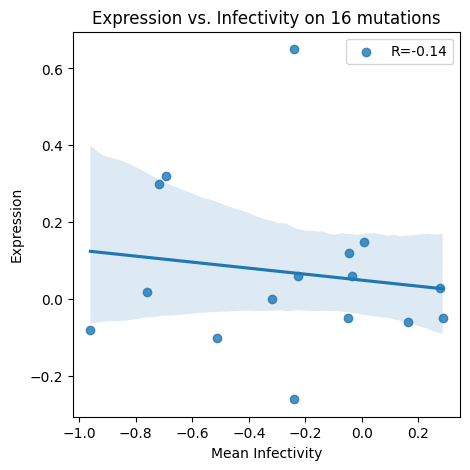

In [37]:
# Infectivity vs Expression
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Infectivity',
            y='Expression',
            data=pd.merge(infectivity, dms, on='Mutation').rename(columns={'Mean':'Mean Infectivity'}),
            label='R={:.2f}'.format(pd.merge(infectivity, dms, on='Mutation')[['Mean','Expression']].corr().values[0,1]),
            ax=ax);
ax.legend()

exp_muts = set(dms.Mutation)
inf_muts = set(infectivity.Mutation)

ax.set_title('Expression vs. Infectivity on {} mutations'.format(len(exp_muts&inf_muts)));

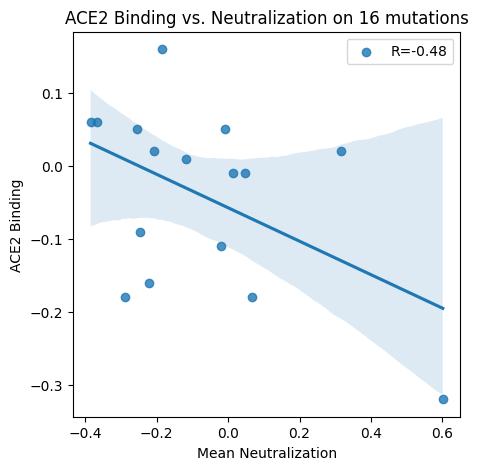

In [38]:
# Neutralization vs ACE2 Binding
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Neutralization',
            y='ACE2 Binding',
            data=pd.merge(neutralization, dms, on='Mutation').rename(columns={'Mean':'Mean Neutralization'}),
            label='R={:.2f}'.format(pd.merge(neutralization, dms, on='Mutation')[['Mean','ACE2 Binding']].corr().values[0,1]),
            ax=ax);
ax.legend()

ace_muts = set(dms.Mutation)
neut_muts = set(neutralization.Mutation)

ax.set_title('ACE2 Binding vs. Neutralization on {} mutations'.format(len(ace_muts&neut_muts)));

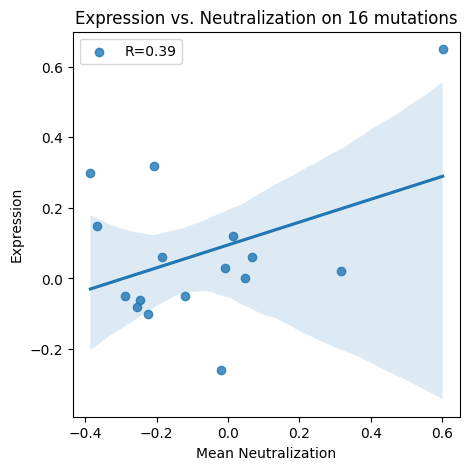

In [39]:
# Neutralization vs Expression
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Neutralization',
            y='Expression',
            data=pd.merge(neutralization, dms, on='Mutation').rename(columns={'Mean':'Mean Neutralization'}),
            label='R={:.2f}'.format(pd.merge(neutralization, dms, on='Mutation')[['Mean','Expression']].corr().values[0,1]),
            ax=ax);
ax.legend()

exp_muts = set(dms.Mutation)
neut_muts = set(neutralization.Mutation)

ax.set_title('Expression vs. Neutralization on {} mutations'.format(len(exp_muts&neut_muts)));

## Compare to Bloom Fitness

In [51]:
filename = 'data/Bloom/aamut_fitness_all.csv'
columns = {'gene':'Gene',
           'aa_site': 'Position',
           'aa_mutation': 'Mutation',
           'delta_fitness': 'Bloom Fitness'}
bloom = pd.read_csv(filename, usecols=columns.keys()).rename(columns=columns)
bloom = bloom[bloom['Gene'] == 'S'].sort_values(by='Position').reset_index(drop=True)

In [52]:
df = pd.merge(neutralization, infectivity, on='Mutation', suffixes = [' Neutralization', ' Infectivity'])
df = pd.merge(df, bloom, on='Mutation')
df[['Mean Neutralization', 'Mean Infectivity', 'Bloom Fitness']].corr()

,Mean Neutralization,Mean Infectivity,Bloom Fitness
Mean Neutralization,1.000000,0.045043,-0.227931
Mean Infectivity,0.045043,1.000000,-0.195692
Bloom Fitness,-0.227931,-0.195692,1.000000


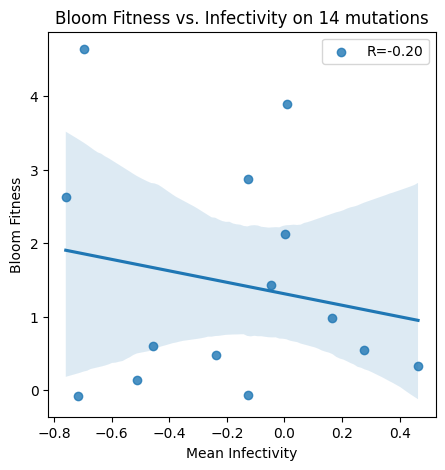

In [55]:
# Infectivity vs Bloom Fitness
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Infectivity',
            y='Bloom Fitness',
            data=pd.merge(infectivity, bloom, on='Mutation').rename(columns={'Mean':'Mean Infectivity'}),
            label='R={:.2f}'.format(pd.merge(infectivity, bloom, on='Mutation')[['Mean','Bloom Fitness']].corr().values[0,1]),
            ax=ax);
ax.legend()

bloom_muts = set(bloom.Mutation)
inf_muts = set(infectivity.Mutation)

ax.set_title('Bloom Fitness vs. Infectivity on {} mutations'.format(len(bloom_muts&inf_muts)));

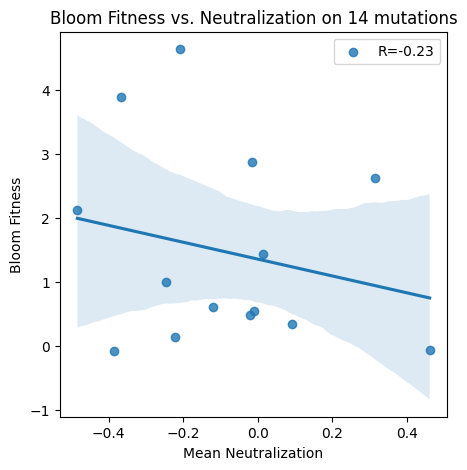

In [56]:
# Neutralization vs Bloom Fitness
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Neutralization',
            y='Bloom Fitness',
            data=pd.merge(neutralization, bloom, on='Mutation').rename(columns={'Mean':'Mean Neutralization'}),
            label='R={:.2f}'.format(pd.merge(neutralization, bloom, on='Mutation')[['Mean','Bloom Fitness']].corr().values[0,1]),
            ax=ax);
ax.legend()

bloom_muts = set(bloom.Mutation)
neut_muts = set(neutralization.Mutation)

ax.set_title('Bloom Fitness vs. Neutralization on {} mutations'.format(len(bloom_muts&neut_muts)));

## Compare to EVE and EVEscape

In [84]:
filename = 'data/EVEscape/spike_evescape_predictions.csv'
columns = {'i':'Position', 
           'wt':'wt',
           'mut':'mut',
           'evescape':'EVEscape',
           'eve':'EVE'}
evescape = pd.read_csv(filename, usecols=columns.keys()).rename(columns=columns).sort_values(by='Position').reset_index(drop=True)
evescape['Mutation'] = evescape['wt'].astype(str) + evescape['Position'].astype(str) + evescape['mut'].astype(str)

In [85]:
df = pd.merge(neutralization, infectivity, on='Mutation', suffixes = [' Neutralization', ' Infectivity'])
df = pd.merge(df, evescape, on='Mutation')
df[['Mean Neutralization', 'Mean Infectivity', 'EVEscape', 'EVE']].corr()

,Mean Neutralization,Mean Infectivity,EVEscape,EVE
Mean Neutralization,1.000000,0.017895,0.116453,0.061737
Mean Infectivity,0.017895,1.000000,-0.336005,-0.246332
EVEscape,0.116453,-0.336005,1.000000,0.505991
EVE,0.061737,-0.246332,0.505991,1.000000


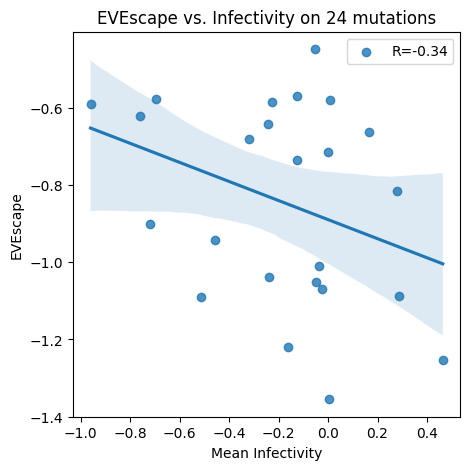

In [89]:
# Infectivity vs EVEscape
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Infectivity',
            y='EVEscape',
            data=pd.merge(infectivity, evescape, on='Mutation').rename(columns={'Mean':'Mean Infectivity'}),
            label='R={:.2f}'.format(pd.merge(infectivity, evescape, on='Mutation')[['Mean','EVEscape']].corr().values[0,1]),
            ax=ax);
ax.legend()

eve_muts = set(evescape.Mutation)
inf_muts = set(infectivity.Mutation)

ax.set_title('EVEscape vs. Infectivity on {} mutations'.format(len(eve_muts&inf_muts)));

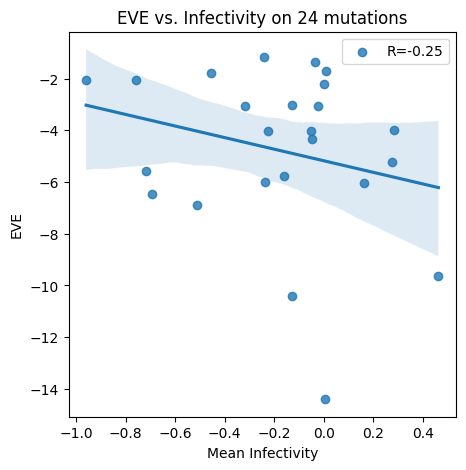

In [88]:
# Infectivity vs EVE
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Infectivity',
            y='EVE',
            data=pd.merge(infectivity, evescape, on='Mutation').rename(columns={'Mean':'Mean Infectivity'}),
            label='R={:.2f}'.format(pd.merge(infectivity, evescape, on='Mutation')[['Mean','EVE']].corr().values[0,1]),
            ax=ax);
ax.legend()

eve_muts = set(evescape.Mutation)
inf_muts = set(infectivity.Mutation)

ax.set_title('EVE vs. Infectivity on {} mutations'.format(len(eve_muts&inf_muts)));

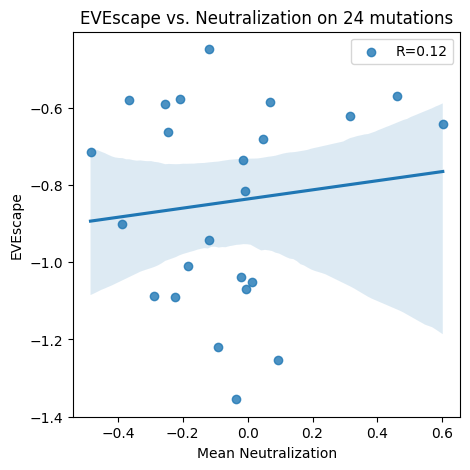

In [90]:
# Neutralization vs EVEscape
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Neutralization',
            y='EVEscape',
            data=pd.merge(neutralization, evescape, on='Mutation').rename(columns={'Mean':'Mean Neutralization'}),
            label='R={:.2f}'.format(pd.merge(neutralization, evescape, on='Mutation')[['Mean','EVEscape']].corr().values[0,1]),
            ax=ax);
ax.legend()

eve_muts = set(evescape.Mutation)
neut_muts = set(neutralization.Mutation)

ax.set_title('EVEscape vs. Neutralization on {} mutations'.format(len(eve_muts&neut_muts)));

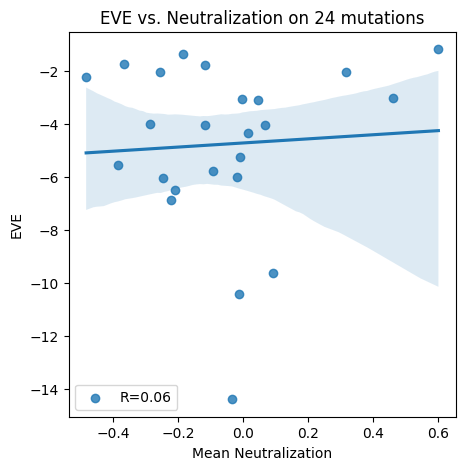

In [91]:
# Neutralization vs EVE
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Neutralization',
            y='EVE',
            data=pd.merge(neutralization, evescape, on='Mutation').rename(columns={'Mean':'Mean Neutralization'}),
            label='R={:.2f}'.format(pd.merge(neutralization, evescape, on='Mutation')[['Mean','EVE']].corr().values[0,1]),
            ax=ax);
ax.legend()

eve_muts = set(evescape.Mutation)
neut_muts = set(neutralization.Mutation)

ax.set_title('EVE vs. Neutralization on {} mutations'.format(len(eve_muts&neut_muts)));